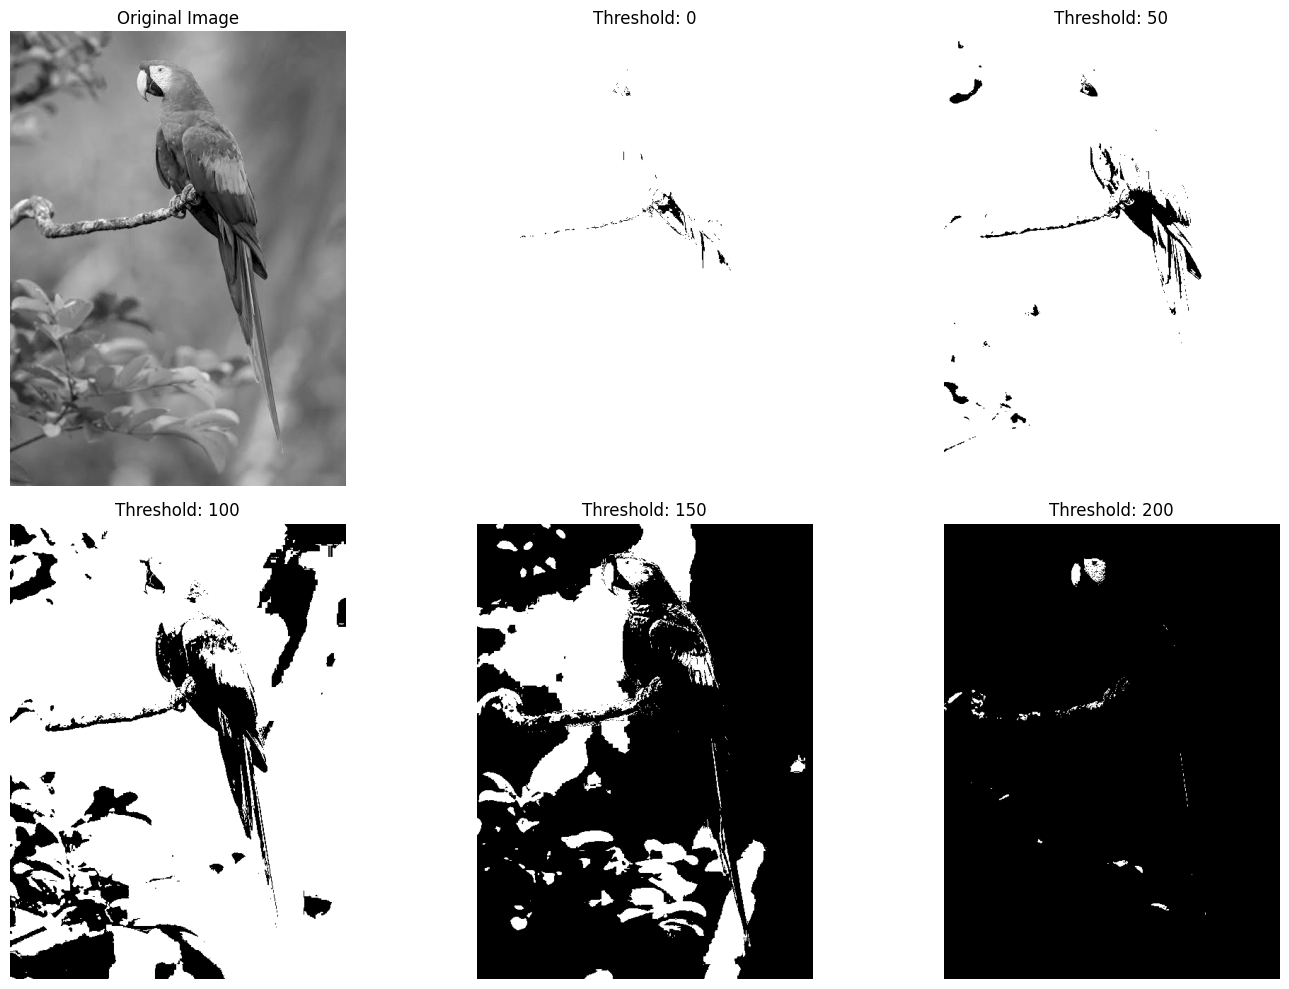

In [19]:
import cv2
import matplotlib.pyplot as plt

# Load the image in grayscale
image= cv2.imread("./images/Parrot.png", cv2.IMREAD_GRAYSCALE)

# Set the threshold values
threshold_values= [0, 50, 100, 150, 200]

# Create a figure with a 2x3 grid of subplots (for 1 original + 5 thresholded images)
fig, axes= plt.subplots(2, 3, figsize= (15, 10))

# Flatten the axes array to make indexing easier in the loop
axes= axes.flatten()

# Display the original image in the first subplot
axes[0].imshow(image, cmap= "gray")
axes[0].set_title("Original Image")
axes[0].axis("off")

# Apply thresholding with different threshold values
for i, threshold_value in enumerate(threshold_values):
    ret, thresh = cv2.threshold(image, threshold_value, 255, cv2.THRESH_BINARY)
    cv2.imwrite(f"./outputs/Threshold_{threshold_value}.png", thresh)
    
    # Display in subplot (i+1 because 0 is the original image)
    axes[i + 1].imshow(thresh, cmap= "gray")
    axes[i + 1].set_title(f"Threshold: {threshold_value}")
    axes[i + 1].axis("off")

plt.tight_layout()
plt.show()

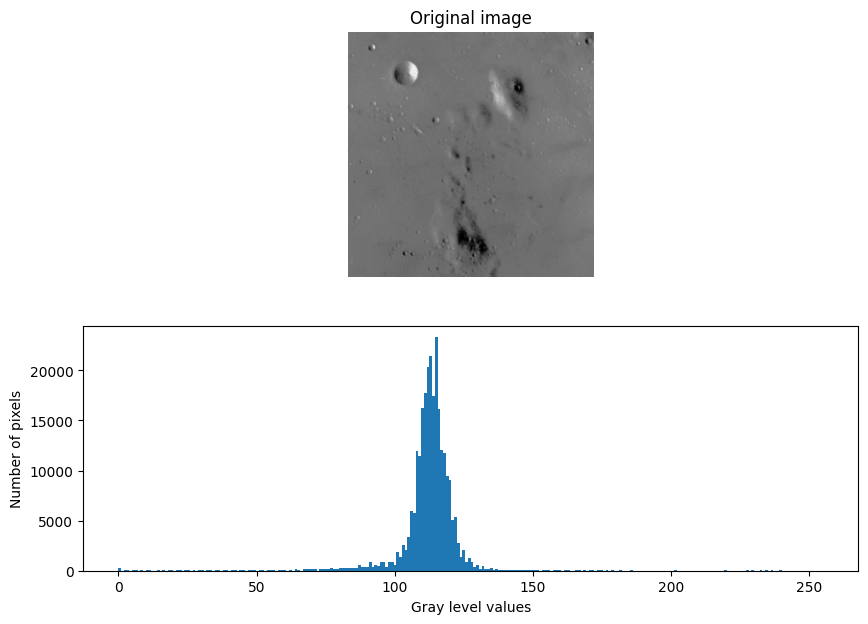

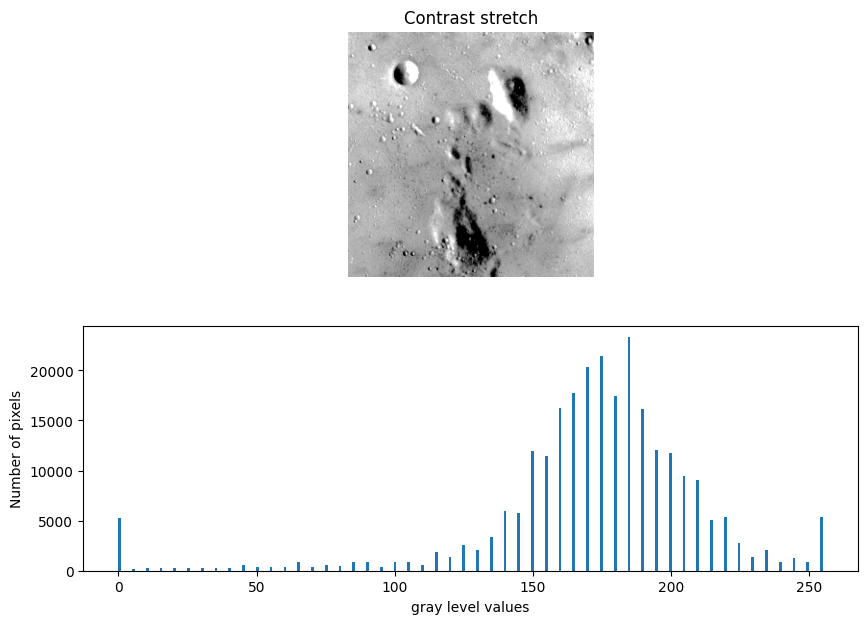

In [21]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from skimage import data, img_as_float
from skimage import exposure

image= data.moon()

p2, p98 = np.percentile(image, (2, 98))
image_rescale= exposure.rescale_intensity(image, in_range= (p2, p98))

fig= plt.figure(figsize= (10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(image, cmap= "gray")
plt.axis("off")
plt.title("Original image")

fig.add_subplot(2, 1, 2)
plt.hist(image.flat, bins= 256, range= (0, 255))
plt.xlabel("Gray level values")
plt.ylabel("Number of pixels")
plt.show()


fig= plt.figure(figsize= (10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(image_rescale, cmap= "gray")
plt.axis("off")
plt.title("Contrast stretch")

fig.add_subplot(2, 1, 2)
plt.hist(image_rescale.flat, bins= 256, range= (0, 255))
plt.xlabel("gray level values")
plt.ylabel("Number of pixels")
plt.show()

# Task#1

Using the same ‘moon image’ Rescale intensity values to include all the intensities
that fall within the 3rd and 80th percentiles, and plot the histogram.

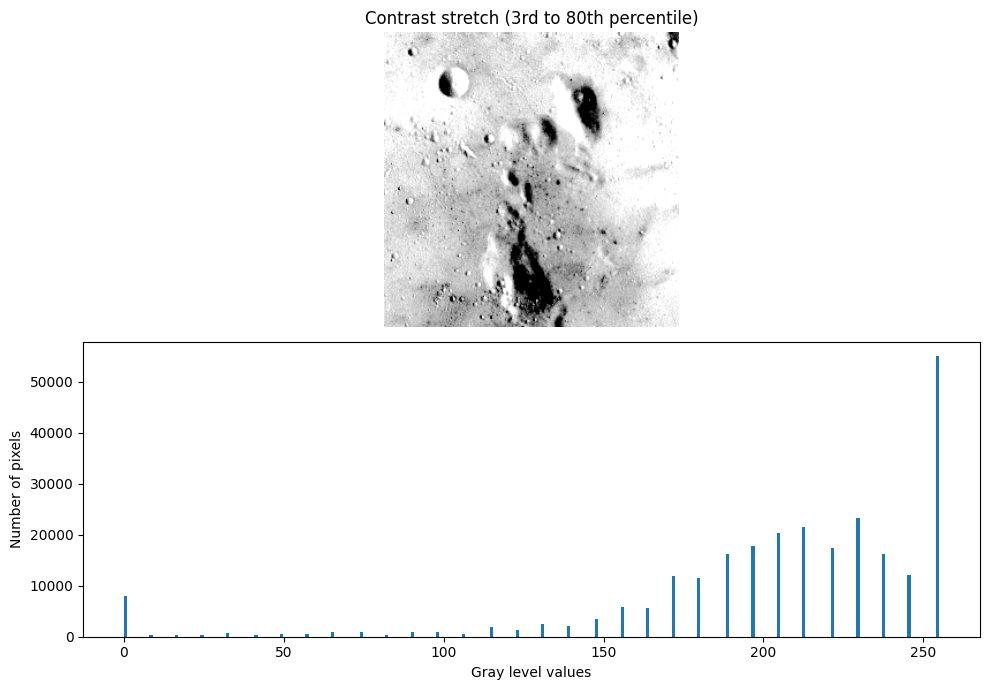

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure

# Load the moon image
img_moon= data.moon()

# Calculate the 3rd and 80th percentiles
p3, p80 = np.percentile(img_moon, (3, 80))

# Rescale intensity values
img_rescale= exposure.rescale_intensity(img_moon, in_range= (p3, p80))

# Plot the rescaled image and its histogram
fig= plt.figure(figsize= (10, 7))

# Image subplot
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap= "gray")
plt.axis("off")
plt.title("Contrast stretch (3rd to 80th percentile)")

# Histogram subplot
fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins= 256, range= (0, 255))
plt.xlabel("Gray level values")
plt.ylabel("Number of pixels")

plt.tight_layout()
plt.show()

# Task#2

Using the same ‘moon image’ and the exposure.equalize_hist function, display the
image and the histogram of the image after flattening the histogram.

**Note:** `equalize_hist` outputs an image with float values from 0.0 to 1.0


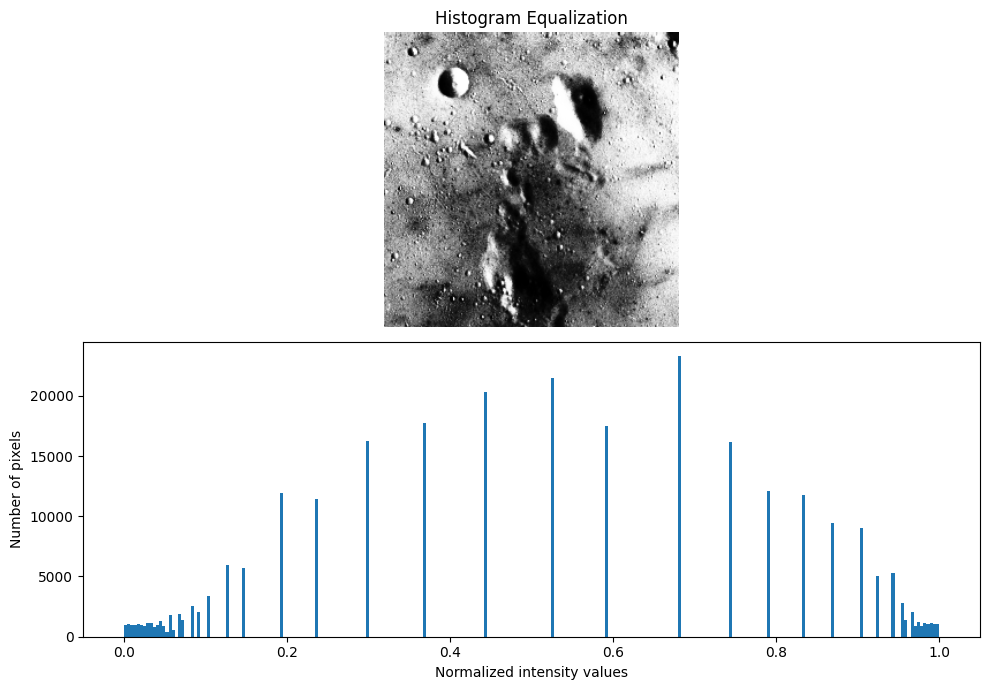

In [27]:
image_eq= exposure.equalize_hist(img_moon)

# Plot the equalized image and its histogram
fig= plt.figure(figsize= (10, 7))

# Image subplot
fig.add_subplot(2, 1, 1)
plt.imshow(image_eq, cmap= "gray")
plt.axis("off")
plt.title("Histogram Equalization")

# Histogram subplot
fig.add_subplot(2, 1, 2)
plt.hist(image_eq.flat, bins= 256, range= (0, 1)) # The range is set to (0, 1) since the intensities are normalized floats
plt.xlabel("Normalized intensity values")
plt.ylabel("Number of pixels")

plt.tight_layout()
plt.show()

# Task#3

Use the rocket (as reference) and Chelsea images (from skimage.data) and
implement histogram matching

**Note:** Since both are color (RGB) images, `channel_axis= -1` ensures matching is done per color channel


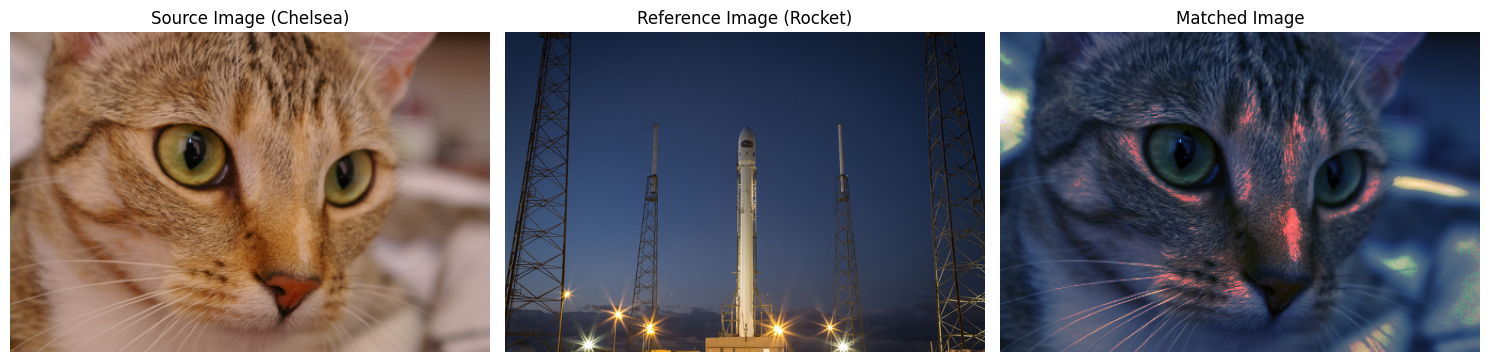

In [32]:
from skimage.exposure import match_histograms

# Load the images
image_chelsea= data.chelsea() # Source image
image_rocket= data.rocket() # Reference image

# Implement histogram matching
matched= match_histograms(image_chelsea, image_rocket, channel_axis= -1)

# Plotting the results
fig, axes = plt.subplots(nrows= 1, ncols= 3, figsize= (15, 5))

axes[0].imshow(image_chelsea)
axes[0].set_title("Source Image (Chelsea)")
axes[0].axis("off")

axes[1].imshow(image_rocket)
axes[1].set_title("Reference Image (Rocket)")
axes[1].axis("off")

axes[2].imshow(matched)
axes[2].set_title("Matched Image")
axes[2].axis("off")

plt.tight_layout()
plt.show()